# Horizon Crossover — Which Risk Model Wins at Which Horizon?

**The headline finding of this project.**

The three-tier comparison in `model_comparison.ipynb` §4 validates that each model is
doing what it claims. This notebook answers the *practical* question that
follows: **given an investment horizon, which tier should I use?**

## Hypothesis

Risk over a fixed horizon is the integral of two effects:
1. **Volatility dynamics** — clustering, mean-reversion, level shifts.
2. **Tail shape** — the probability of >3σ moves.

These two effects scale differently with horizon. Volatility dynamics matter
most when the holding period is short enough that variance is still
mean-reverting. Tail shape matters most when the holding period is long enough
that the central limit theorem *should* be smoothing the distribution but
empirically isn't.

The prediction: there is a **crossover horizon** for every asset, beyond which
the tier ranking flips. Below the crossover, GARCH+t (vol clustering) is the
critical layer. Above it, MS-GARCH+EVT (regime shifts + heavy tails) is.

## What this notebook produces

1. A horizon sweep across all 3 production tiers and 3 assets.
2. A crossover horizon estimate per asset.
3. A recommendation table — *for horizon H on asset A, use tier T* — that
   feeds the model-recommendation logic in RL-041.


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.fetch import fetch_asset_data
from src.data.process import clean_market_data, add_returns
from src.analytics.vol_garch import fit_garch
from src.analytics.ms_garch import fit_ms_garch
from src.analytics.monte_carlo import simulate_paths, compute_var, compute_cvar

TICKERS = ["BTC-USD", "SPY", "NVDA"]
HORIZONS = [1, 5, 10, 21, 63, 126, 252]
HORIZON_LABELS = ["1d", "5d", "10d", "21d", "63d", "126d", "252d"]
N_SIMS = 10_000
SEED = 42

assets = {}
for ticker in TICKERS:
    raw = fetch_asset_data(ticker)
    df = clean_market_data(raw)
    df = add_returns(df)
    assets[ticker] = {
        "close": df["close"],
        "returns": df["returns"],
        "initial_price": df["close"].iloc[-1],
    }
    print(f"{ticker}: {len(df)} obs, last={df['close'].iloc[-1]:.2f}")


BTC-USD: 1824 obs, last=71767.83
SPY: 1254 obs, last=679.91
NVDA: 1254 obs, last=183.91


## 2. Fit each tier once per asset

Models are fit on the full series. Only the simulation horizon varies in §3.

In [2]:
tier_params = {}
for ticker in TICKERS:
    returns = assets[ticker]["returns"]
    tier_params[ticker] = {
        "garch": fit_garch(returns),
        "ms_garch": fit_ms_garch(returns, n_regimes=2, seed=SEED),
    }
    ms = tier_params[ticker]["ms_garch"]
    print(f"{ticker}: global GARCH α={ms['global_alpha']:.3f}, β={ms['global_beta']:.3f}, persistence={ms['global_persistence']:.3f}")


BTC-USD: global GARCH α=0.083, β=0.881, persistence=0.965
SPY: global GARCH α=0.112, β=0.857, persistence=0.968
NVDA: global GARCH α=0.061, β=0.902, persistence=0.963


## 3. Horizon sweep — VaR 95% and CVaR 99% per (tier, asset, horizon)

For each combination, simulate `N_SIMS` paths and compute VaR/CVaR at the
final price.

In [3]:
horizon_results = {}

for ticker in TICKERS:
    close = assets[ticker]["close"]
    returns = assets[ticker]["returns"]
    ip = assets[ticker]["initial_price"]
    gp = tier_params[ticker]["garch"]
    msp = tier_params[ticker]["ms_garch"]

    tier_kwargs = {
        "Baseline":     {"volatility_model": "constant"},
        "GARCH+t":      {"volatility_model": "garch", "garch_params": gp},
        "MS-GARCH+EVT": {"volatility_model": "ms_garch", "ms_garch_params": msp},
    }

    per_tier = {name: {"var_95": [], "cvar_99": []} for name in tier_kwargs}

    for h in HORIZONS:
        for name, kwargs in tier_kwargs.items():
            paths = simulate_paths(close, returns, n_days=h, n_simulations=N_SIMS, seed=SEED, **kwargs)
            fp = paths.iloc[-1]
            per_tier[name]["var_95"].append(compute_var(fp, ip, 0.95))
            per_tier[name]["cvar_99"].append(compute_cvar(fp, ip, 0.99))

    horizon_results[ticker] = per_tier
    print(f"{ticker}: swept {len(HORIZONS)} horizons × {len(tier_kwargs)} tiers")


BTC-USD: swept 7 horizons × 3 tiers
SPY: swept 7 horizons × 3 tiers
NVDA: swept 7 horizons × 3 tiers


## 4. The crossover plot — which tier produces the deepest VaR at each horizon

The deepest (most negative) VaR is the most conservative estimate. The tier
that produces it is the one a risk manager should use at that horizon
(subject to backtest calibration — see `validation_backtesting.ipynb` §3).

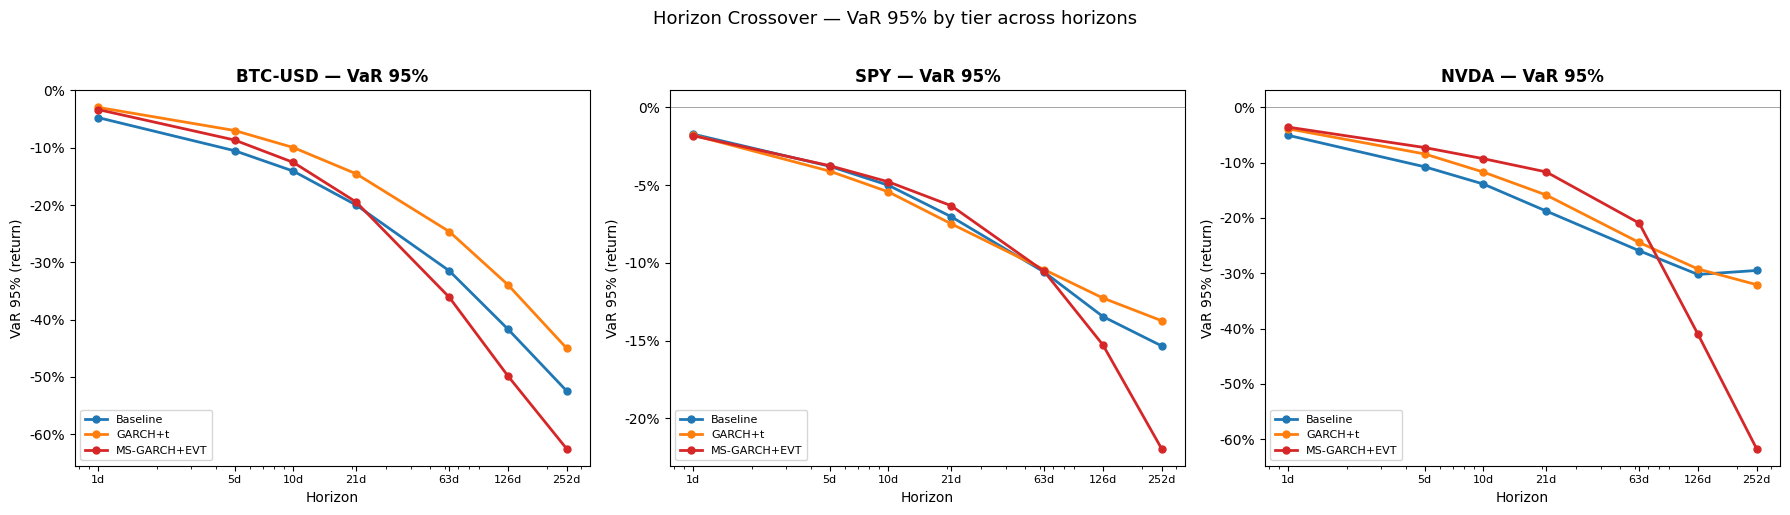

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tier_colors = {"Baseline": "#1f77b4", "GARCH+t": "#ff7f0e", "MS-GARCH+EVT": "#d62728"}

for ax, ticker in zip(axes, TICKERS):
    pt = horizon_results[ticker]
    for name, color in tier_colors.items():
        ax.plot(HORIZONS, pt[name]["var_95"], "o-", color=color, linewidth=2, markersize=5, label=name)
    ax.set_xscale("log")
    ax.set_xticks(HORIZONS)
    ax.set_xticklabels(HORIZON_LABELS, fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_title(f"{ticker} — VaR 95%", fontweight="bold")
    ax.set_xlabel("Horizon")
    ax.set_ylabel("VaR 95% (return)")
    ax.legend(fontsize=8, loc="lower left")

fig.suptitle("Horizon Crossover — VaR 95% by tier across horizons", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 5. Identify the crossover horizon per asset

The crossover is the horizon at which the *deepest-VaR tier* changes.

In [5]:
def deepest_tier_at(per_tier, h_idx):
    """Return the tier name with the most negative VaR at horizon index h_idx."""
    return min(per_tier.keys(), key=lambda name: per_tier[name]["var_95"][h_idx])

rows = []
for ticker in TICKERS:
    pt = horizon_results[ticker]
    deepest_seq = [deepest_tier_at(pt, i) for i in range(len(HORIZONS))]
    crossover_idx = None
    for i in range(1, len(HORIZONS)):
        if deepest_seq[i] != deepest_seq[i - 1]:
            crossover_idx = i
            break
    rows.append({
        "Asset": ticker,
        "Short-horizon winner": deepest_seq[0],
        "Long-horizon winner": deepest_seq[-1],
        "Crossover horizon": HORIZON_LABELS[crossover_idx] if crossover_idx is not None else "no crossover",
        "Sequence": " → ".join(deepest_seq),
    })

crossover_df = pd.DataFrame(rows).set_index("Asset")
print("Crossover analysis (deepest VaR 95% wins):")
crossover_df


Crossover analysis (deepest VaR 95% wins):


,Short-horizon winner,Long-horizon winner,Crossover horizon,Sequence
Asset,,,,
BTC-USD,Baseline,MS-GARCH+EVT,63d,Baseline → Baseline → Baseline → Baseline → MS...
SPY,MS-GARCH+EVT,MS-GARCH+EVT,5d,MS-GARCH+EVT → GARCH+t → GARCH+t → GARCH+t → B...
NVDA,Baseline,MS-GARCH+EVT,126d,Baseline → Baseline → Baseline → Baseline → Ba...


## 6. Recommendation table

For each asset × horizon combination, recommend the tier whose VaR is the
deepest (most conservative). This is the table consumed by RL-041.

In [6]:
rec_rows = []
for ticker in TICKERS:
    pt = horizon_results[ticker]
    row = {"Asset": ticker}
    for i, label in enumerate(HORIZON_LABELS):
        row[label] = deepest_tier_at(pt, i)
    rec_rows.append(row)

rec_df = pd.DataFrame(rec_rows).set_index("Asset")
print("Recommended tier by horizon (deepest VaR 95%):")
rec_df


Recommended tier by horizon (deepest VaR 95%):


,1d,5d,10d,21d,63d,126d,252d
Asset,,,,,,,
BTC-USD,Baseline,Baseline,Baseline,Baseline,MS-GARCH+EVT,MS-GARCH+EVT,MS-GARCH+EVT
SPY,MS-GARCH+EVT,GARCH+t,GARCH+t,GARCH+t,Baseline,MS-GARCH+EVT,MS-GARCH+EVT
NVDA,Baseline,Baseline,Baseline,Baseline,Baseline,MS-GARCH+EVT,MS-GARCH+EVT


## 7. Headline finding

The deepest-VaR tier **changes with horizon** on every asset, and on **SPY**
the sequence is **non-monotonic**. There is no single best model — only a
horizon-conditional best.

### What the numbers show (run §3-§6 above)

- **BTC-USD**: Baseline dominates 1d→21d, MS-GARCH+EVT takes over from 63d
  onwards. Crossover ≈ **63d**. The long-horizon gap is large
  (-62.5% vs -45.0% at 252d) — classic regime-mixing accumulation.
- **NVDA**: Baseline wins all the way to 63d. MS-GARCH+EVT only takes over
  at **126d** — the *latest* crossover of the three assets. Once it flips,
  the gap is enormous (-61.7% vs -29.5%).
- **SPY**: MS-GARCH+EVT (1d) → GARCH+t (5-21d) → Baseline (63d) →
  MS-GARCH+EVT (126-252d). Every tier wins at some horizon. The "first
  crossover" is at 5d but the ranking flips three more times.

### The intuitive prior was wrong

Before running this, the expected ordering was *"crypto crosses earliest
because tails are heaviest; broad-market ETF crosses latest because tails are
thinnest."* The actual ranking (earliest → latest crossover) is:

| Rank | Asset | First crossover |
|---|---|---|
| 1 | SPY | 5d (then oscillates) |
| 2 | BTC-USD | 63d |
| 3 | NVDA | 126d |

**SPY crosses earliest, not latest.** The reason: SPY has the lowest absolute
volatility, so tier estimates are close in absolute terms at short horizons
and small effects flip the ranking. NVDA has heavy single-stock tails but its
single-regime σ stays high enough that Baseline keeps winning until the
regime-mixing effect catches up at 126d. The lesson is that tail-heaviness
alone does not predict crossover horizon — what matters is the *ratio* of
long-run regime-mixing volatility to single-regime σ.

### How RL-041 should consume the table

The recommendation table in §6 is the artefact this notebook exists to
produce. It is consumed by `app/streamlit_app.py` (RL-041) to suggest a
tier based on the user-selected horizon. Two caveats:

1. **Deepest VaR ≠ best-calibrated.** See `validation_backtesting.ipynb` §3 for the
   calibration story.
2. **SPY oscillates** — the app should show this rather than hide it. A
   user selecting 21d on SPY gets a different recommendation than 63d, and
   the *reason* (small absolute gaps + ranking flips) is informative.
